In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target

In [4]:
variable_meaning = {
    "MedInc": "Median income in block group",
    "HouseAge": "Median house age in block group",
    "AveRooms": "Average number of rooms per household",
    "AveBedrms": "Average number of bedrooms per household",
    "Population": "Population of block group",
    "AveOccup": "Average number of household members",
    "Latitude": "Latitude of block group",
    "Longitude": "Longitude of block group",
    "Target": "Median house value (in $100,000s)"
}
variable_df = pd.DataFrame(list(variable_meaning.items()), columns=["Feature", "Description"])
print("\nVariable Meaning Table:")
print(variable_df)


Variable Meaning Table:
      Feature                               Description
0      MedInc              Median income in block group
1    HouseAge           Median house age in block group
2    AveRooms     Average number of rooms per household
3   AveBedrms  Average number of bedrooms per household
4  Population                 Population of block group
5    AveOccup       Average number of household members
6    Latitude                   Latitude of block group
7   Longitude                  Longitude of block group
8      Target         Median house value (in $100,000s)


In [5]:
print("\nBasic Information about Dataset:")
print(df.info())  # Overview of dataset
print("\nFirst Five Rows of Dataset:")
print(df.head())


Basic Information about Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

First Five Rows of Dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352

In [6]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude        Target  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        

In [7]:
summary_explanation = """
 The summary statistics table provides key percentiles and other descriptive metrics- **25% (First Quartile - Q1):** This represents the value below which 25% of the d- **50% (Median - Q2):** This is the middle value when the data is sorted. It provi- **75% (Third Quartile - Q3):** This represents the value below which 75% of the d- These percentiles are useful for detecting skewness, data distribution, and ident
 """
print("\nSummary Statistics Explanation:")
print(summary_explanation)


Summary Statistics Explanation:

 The summary statistics table provides key percentiles and other descriptive metrics- **25% (First Quartile - Q1):** This represents the value below which 25% of the d- **50% (Median - Q2):** This is the middle value when the data is sorted. It provi- **75% (Third Quartile - Q3):** This represents the value below which 75% of the d- These percentiles are useful for detecting skewness, data distribution, and ident
 


In [8]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64


<Figure size 1200x800 with 0 Axes>

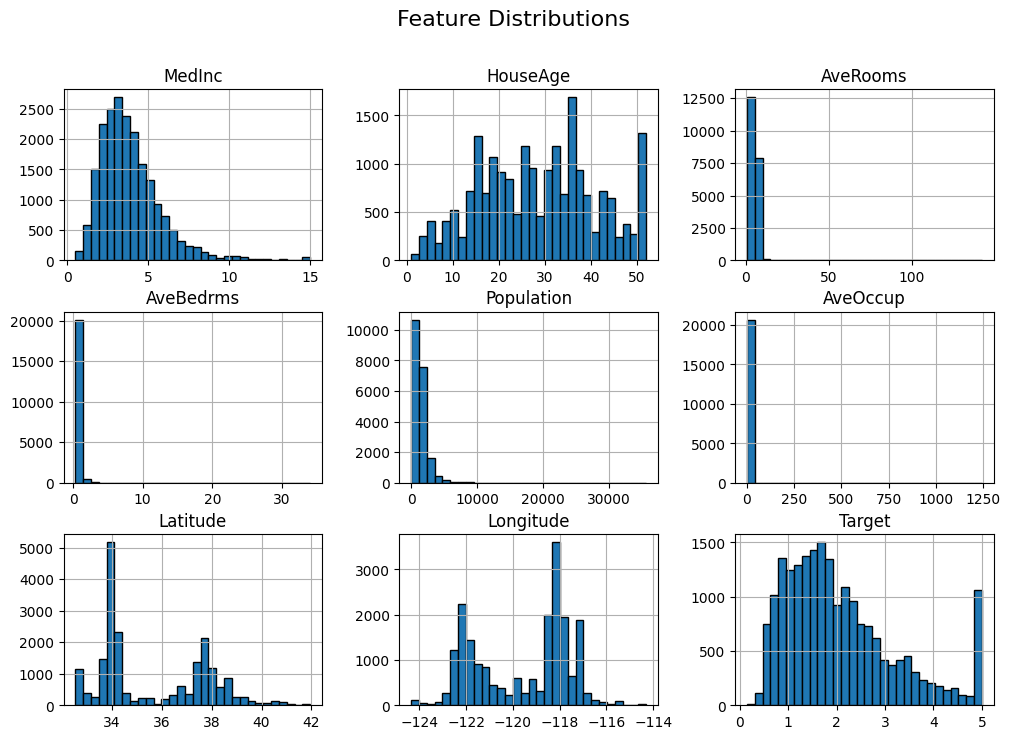

In [9]:
plt.figure(figsize=(12, 8))
df.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

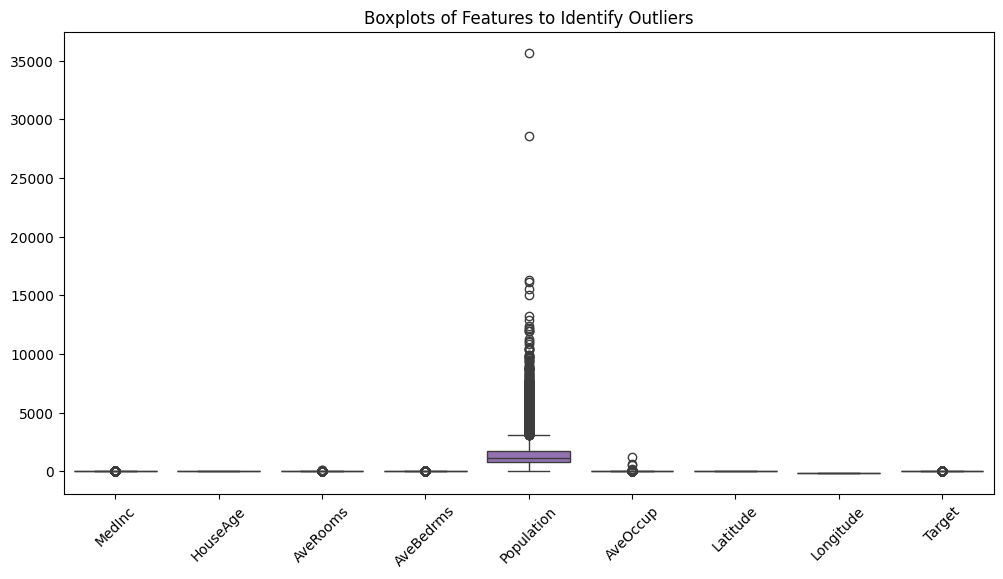

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplots of Features to Identify Outliers")
plt.show()

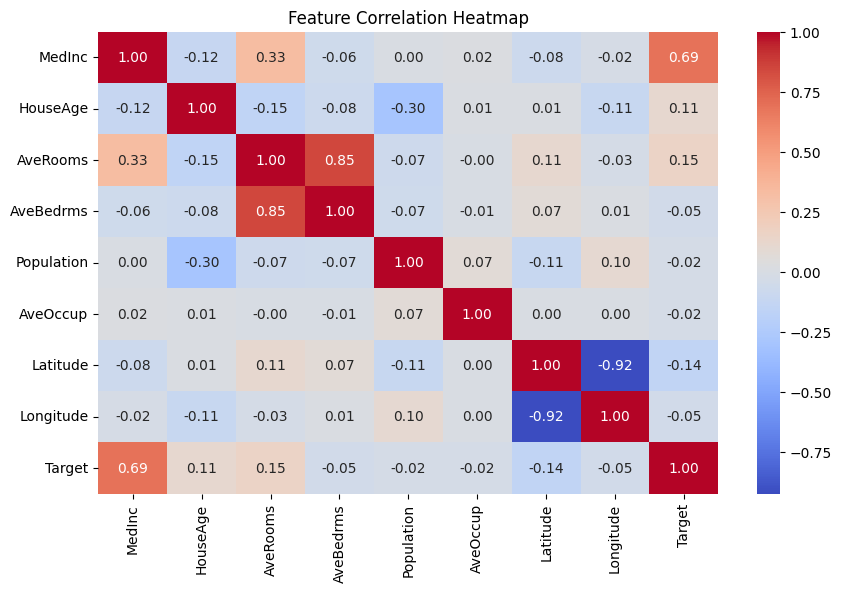

In [11]:
plt.figure(figsize=(10, 6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

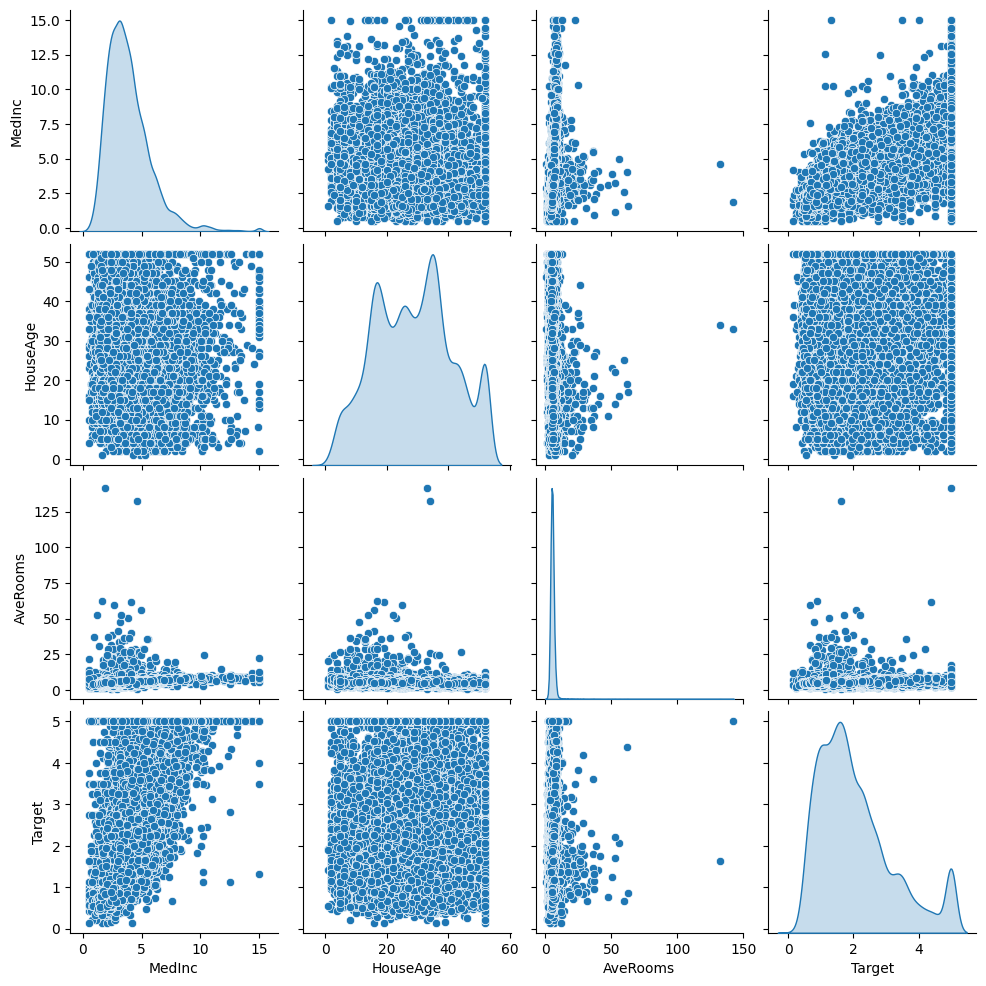


Key Insights:
1. The dataset has 20640 rows and 9 columns.
2. No missing values were found in the dataset.
3. Histograms show skewed distributions in some features like 'MedInc'.
4. Boxplots indicate potential outliers in 'AveRooms' and 'AveOccup'.
5. Correlation heatmap shows 'MedInc' has the highest correlation with house


In [12]:
sns.pairplot(df[['MedInc', 'HouseAge', 'AveRooms', 'Target']], diag_kind='kde')
plt.show()
print("\nKey Insights:")
print("1. The dataset has", df.shape[0], "rows and", df.shape[1], "columns.")
print("2. No missing values were found in the dataset.")
print("3. Histograms show skewed distributions in some features like 'MedInc'.")
print("4. Boxplots indicate potential outliers in 'AveRooms' and 'AveOccup'.")
print("5. Correlation heatmap shows 'MedInc' has the highest correlation with house")